In [10]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config.paths import MERGED_CSV, FIGURES_DIR, RESULTS_DIR, MODELS_DIR
from src.models.risk_classifier import (
    load_merged, train_hazard_classifier, train_moid_regressor, composite_risk_score,
    FEATURES_FULL, FEATURES_NO_LEAK, MOID_FEATURES, XGBOOST_AVAILABLE
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

df = load_merged(MERGED_CSV)
print(df.shape)

XGBoost available: True
(27422, 49)


In [11]:
model_full, metrics_full, pred_full, proba_full = train_hazard_classifier(
    df, FEATURES_FULL, label="full_with_leakage"
)
print("Scenario A (full, leakage-prone):")
print(metrics_full)

Scenario A (full, leakage-prone):
{'label': 'full_with_leakage', 'accuracy': 0.9969111969111969, 'balanced_accuracy': 0.9914874919444607, 'precision': 0.9920159680638723, 'recall': 0.9841584158415841, 'f1': 0.9880715705765407, 'roc_auc': 0.9990128302771105, 'xgboost_used': True}


In [12]:
model_nl, metrics_nl, pred_nl, proba_nl = train_hazard_classifier(
    df, FEATURES_NO_LEAK, label="no_leakage"
)
print("Scenario B (no-leakage, honest):")
print(metrics_nl)

Scenario B (no-leakage, honest):
{'label': 'no_leakage', 'accuracy': 0.9487773487773488, 'balanced_accuracy': 0.9503500497978792, 'precision': 0.7332317073170732, 'recall': 0.9524752475247524, 'f1': 0.8285960378983634, 'roc_auc': 0.9827845802331713, 'xgboost_used': True}


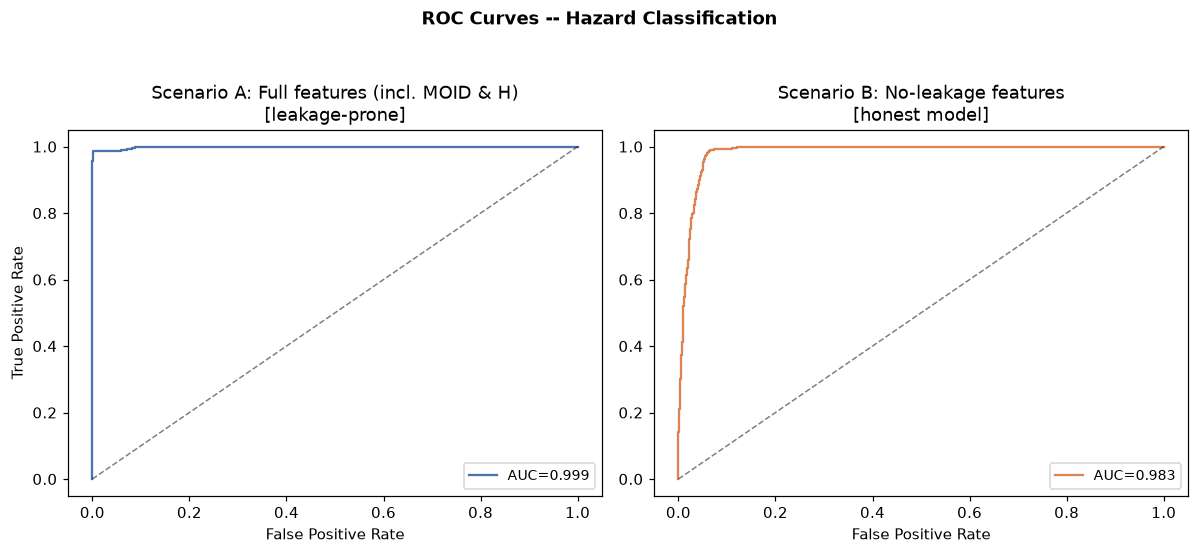

In [13]:
from sklearn.metrics import roc_curve

test_df = df[df["is_future"] == True]
fpr_full, tpr_full, _ = roc_curve(test_df["pha"], proba_full)
fpr_nl, tpr_nl, _ = roc_curve(test_df["pha"], proba_nl)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(fpr_full, tpr_full, color="#4C72B0", label=f"AUC={metrics_full['roc_auc']:.3f}")
axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
axes[0].set_title("Scenario A: Full features (incl. MOID & H)\n[leakage-prone]")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].legend(fontsize=9)

axes[1].plot(fpr_nl, tpr_nl, color="#DD8452", label=f"AUC={metrics_nl['roc_auc']:.3f}")
axes[1].plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
axes[1].set_title("Scenario B: No-leakage features\n[honest model]")
axes[1].set_xlabel("False Positive Rate"); axes[1].legend(fontsize=9)
plt.suptitle("ROC Curves -- Hazard Classification", fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "risk_01_roc_comparison.png", bbox_inches="tight")
plt.show()

In [14]:
moid_model, moid_metrics, moid_pred = train_moid_regressor(df, MOID_FEATURES, log_target=True)
print("Best model:", moid_metrics["best_model"])
print("Metrics:", {k:v for k,v in moid_metrics.items() if k != "all_candidates"})
print()
print("All candidates compared:")
for name, m in moid_metrics["all_candidates"].items():
    print(f"  {name}: R2={m['R2']:.4f}, MAE={m['MAE']:.5f}, RMSE={m['RMSE']:.5f}")

Best model: random_forest
Metrics: {'MAE': 0.0070833507964367295, 'RMSE': 0.014034262702328108, 'R2': 0.6204750437660381, 'best_model': 'random_forest', 'xgboost_used': True}

All candidates compared:
  xgboost_or_hgb: R2=0.4993, MAE=0.00979, RMSE=0.01612
  random_forest: R2=0.6205, MAE=0.00708, RMSE=0.01403


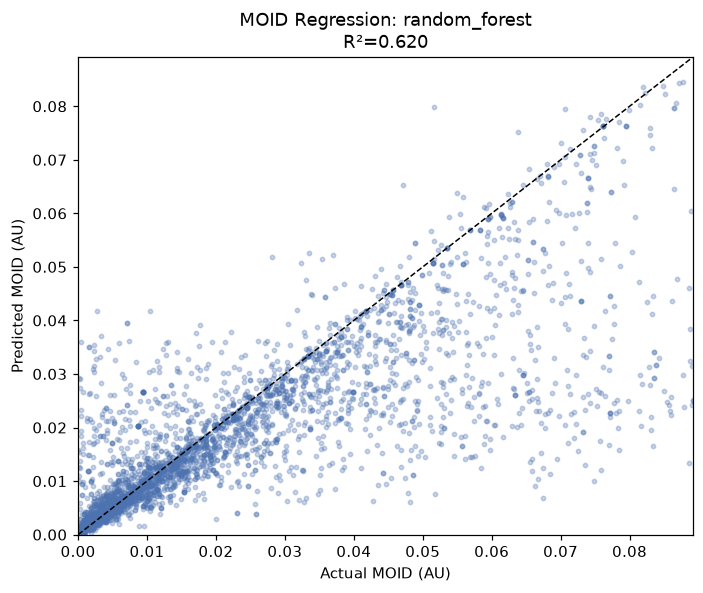

In [15]:
test_df_moid = df[df["is_future"] == True]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(test_df_moid["moid_au"], moid_pred, s=8, alpha=0.3, color="#4C72B0")
lims = [0, test_df_moid["moid_au"].quantile(0.99)]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual MOID (AU)"); ax.set_ylabel("Predicted MOID (AU)")
ax.set_title(f"MOID Regression: {moid_metrics['best_model']}\nR²={moid_metrics['R2']:.3f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "risk_02_moid_regression.png")
plt.show()

In [16]:
test_out = df[df["is_future"] == True].copy()
test_out["predicted_hazard_probability"] = proba_nl
test_out["predicted_moid_au"] = moid_pred
test_out["risk_score"] = composite_risk_score(
    test_out["diameter_km"], test_out["velocity_km_s"],
    test_out["predicted_moid_au"], test_out["predicted_hazard_probability"]
)

export_cols = ["spkid", "full_name", "designation", "close_approach_date", "year",
                "a", "e", "i", "q", "ad", "per_y", "moid_au", "H", "diameter_km",
                "distance_au", "velocity_km_s", "condition_code", "pha",
                "predicted_hazard_probability", "predicted_moid_au", "risk_score"]
export_cols = [c for c in export_cols if c in test_out.columns]
test_out_export = test_out[export_cols].sort_values("risk_score", ascending=False).reset_index(drop=True)

test_out_export.to_csv(RESULTS_DIR / "asteroid_predictions_for_simulation.csv", index=False)
print(f"Saved {len(test_out_export)} rows to results/asteroid_predictions_for_simulation.csv")
test_out_export.head(10)

Saved 3885 rows to results/asteroid_predictions_for_simulation.csv


,spkid,full_name,designation,close_approach_date,year,a,e,i,q,ad,...,moid_au,H,diameter_km,distance_au,velocity_km_s,condition_code,pha,predicted_hazard_probability,predicted_moid_au,risk_score
0,20001981,1981 Midas (1973 EA),1981,2032-09-14 14:57:00,2032,1.7760,0.6505,39.82,0.621,2.93,...,0.00277,15.28,3.400000,0.086350,26.417998,0.0,1,0.998411,0.005282,10.000000
1,20004953,4953 (1990 MU),4953,2027-06-06 22:43:00,2027,1.6210,0.6575,24.38,0.555,2.69,...,0.02450,14.88,3.753712,0.030830,23.817116,0.0,1,0.997154,0.014330,9.997426
2,20002329,2329 Orthos (1976 WA),2329,2032-09-20 09:23:00,2032,2.4110,0.6533,24.46,0.836,3.99,...,0.09360,14.57,4.329731,0.094959,20.186350,0.0,0,0.992810,0.017661,9.994852
3,20242450,242450 (2004 QY2),242450,2029-07-15 18:05:00,2029,1.0840,0.4771,37.03,0.567,1.60,...,0.04790,14.64,2.914000,0.047127,23.285407,0.0,1,0.984699,0.007806,9.992278
4,20005731,5731 Zeus (1988 VP4),5731,2029-12-08 14:39:00,2029,2.2650,0.6524,11.20,0.787,3.74,...,0.06470,15.47,5.231000,0.098839,18.181875,0.0,0,0.755160,0.030122,9.989704
5,20144332,144332 (2004 DV24),144332,2035-09-10 20:18:00,2035,1.4230,0.2897,55.89,1.011,1.84,...,0.00560,16.60,1.700047,0.093649,29.981474,0.0,1,0.997295,0.005290,9.987130
6,20143649,143649 (2003 QQ47),143649,2031-03-19 05:27:00,2031,1.0850,0.1870,62.10,0.882,1.29,...,0.00163,17.39,1.181574,0.086537,31.177327,0.0,1,0.994626,0.003011,9.984556
7,20087684,87684 (2000 SY2),87684,2031-09-13 01:10:00,2031,0.8587,0.6427,19.22,0.307,1.41,...,0.04680,15.96,2.282764,0.050427,21.912739,0.0,1,0.987740,0.015858,9.981982
8,20001917,1917 Cuyo (1968 AA),1917,2030-10-06 07:09:00,2030,2.1490,0.5055,23.96,1.063,3.24,...,0.07170,14.38,5.700000,0.089665,14.447204,0.0,0,0.247489,0.059897,9.979408
9,20387505,387505 (1998 KN3),387505,2033-02-26 22:59:00,2033,1.5420,0.8734,2.29,0.195,2.89,...,0.01830,18.78,1.060000,0.064815,29.814496,0.0,1,0.999862,0.006637,9.976834


In [17]:
from src.data.fetch_cneos import fetch_sentry_table

# Uncomment to run locally:
sentry_df = fetch_sentry_table()
our_top_designations = set(test_out_export["designation"].head(20))
sentry_designations = set(sentry_df["des"]) if len(sentry_df) > 0 else set()
overlap = our_top_designations & sentry_designations
print(f"Overlap between our top-20 risk_score list and JPL's real Sentry table: {len(overlap)}")
print("Note: a low overlap is EXPECTED and not necessarily a flaw -- our composite")
print("risk_score is a different (illustrative) metric than Sentry's true impact")
print("probability, which requires detailed Virtual-Impactor orbit-solution analysis")
print("our model does not perform. Treat this as a sanity-check/discussion point,")
print("not a validation that our score should match Sentry's listing.")

Overlap between our top-20 risk_score list and JPL's real Sentry table: 0
Note: a low overlap is EXPECTED and not necessarily a flaw -- our composite
risk_score is a different (illustrative) metric than Sentry's true impact
probability, which requires detailed Virtual-Impactor orbit-solution analysis
our model does not perform. Treat this as a sanity-check/discussion point,
not a validation that our score should match Sentry's listing.


In [18]:
joblib.dump(model_nl, MODELS_DIR / "hazard_classifier_no_leak.joblib")
joblib.dump(moid_model, MODELS_DIR / "moid_regressor.joblib")
print(f"Models saved to {MODELS_DIR}")

Models saved to C:\Users\SATYAM\Desktop\ISM_Assignments\neo-forecasting\python\models
